# Answers week 6

* Red text: session quiz question
* Cell with code open: needs to be checked by TA
* Missing numbers: coursework questions

#### <span style="color:red"> *Question 6.1*

Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   

SIMPLE= True
BITPIX= 16
NAXIS= 2
NAXIS1= 530
NAXIS2= 530

The shape of dat is: (530, 530)
The dtype of dat is: >i2, which has the name: int16

DescribeResult(nobs=280900, minmax=(1507, 15752), mean=4795.924268422927, variance=3416049.866051364, skewness=2.1344311442506223, kurtosis=5.202208842285202)

Statistics: 
Minimum = 1507 
Maximum = 15752 
Mean = 4795.924268422927 
Standard deviation = 1848.2558984219054 
Median = 4102.0 
Mode = 3551


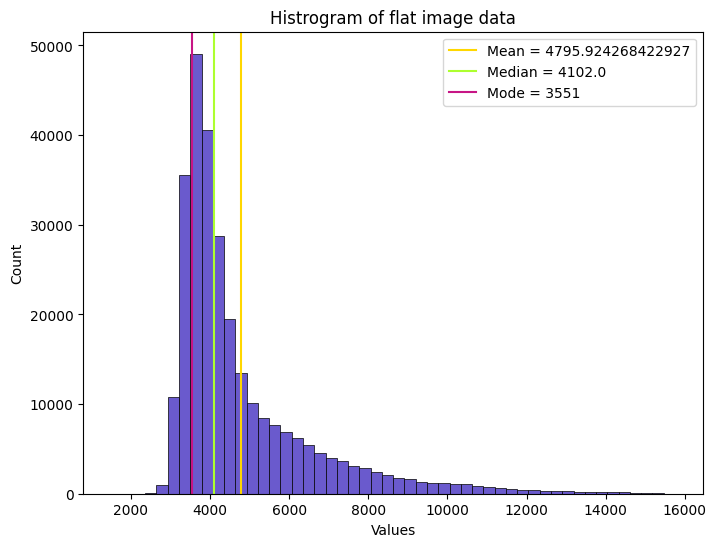

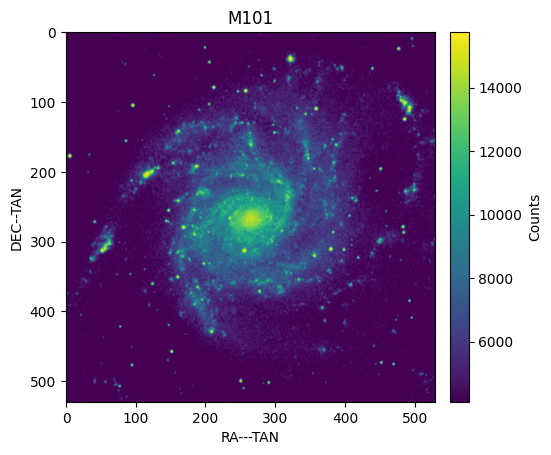

In [21]:
from astropy.io import fits
import numpy as np
from scipy import stats
from matplotlib.pyplot import figure, show
from matplotlib.axes import Axes
from mpl_toolkits.axes_grid1 import make_axes_locatable

hdulist = fits.open('m101.fits')  # Open file
hdulist.info()  # Display info
hdr = hdulist[0].header  # Get first row of info.
print()

for key in hdr[:5]:
    print(f"{key}= {hdr[key]}")  # Print first 5 lines of primary header

dat = hdulist[0].data
dat_type = dat.dtype  # Gets the order and type of number
dat_dtype = np.dtype(dat_type)  # Specifically gets the name of the type of number
print(f"\nThe shape of dat is: {dat.shape}")  # Print shape
print(f"The dtype of dat is: {dat_type}, which has the name: {dat_dtype.name}\n")

flat_data = dat.flatten()
s = stats.describe(flat_data)
Median = np.median(flat_data)  # Get middle value
nobs, (Minval, Maxval), Mean, Var, Skew, Kurt = stats.describe(flat_data)  # Unpack all values, mind that the variance is the (standard deviation)^2
Mode, Counts = stats.mode(flat_data)  # Get most frequent value and the count
print(s)
print(f"\nStatistics: \nMinimum = {Minval} \nMaximum = {Maxval} \nMean = {Mean} \nStandard deviation = {Var**0.5} \nMedian = {Median} \nMode = {Mode}")

hdr['BUNIT'] = "Counts"  # Add BUNIT with the value "Counts" to the header

# Plot the histogram

fig = figure(figsize=(8, 6))  # Create figure
frame = fig.add_subplot(1, 1, 1)  # Define an axis, which I called frame

frame.hist(flat_data, bins=50, color='slateblue', edgecolor='black', linewidth=0.5)
frame.axvline(Mean, color='gold', label=f"Mean = {Mean}")
frame.axvline(Median, color='greenyellow', label=f"Median = {Median}")
frame.axvline(Mode, color='mediumvioletred', label=f"Mode = {Mode}")

# Plot labels, title and legend.

frame.set_title("Histrogram of flat image data")
frame.set_xlabel("Values")
frame.set_ylabel("Count")
frame.legend()

show()

# Plot the image with float data points.

image_data = np.asarray(dat, dtype=float)
im_median = np.median(image_data)

fig2 = figure()
frame2 = fig2.add_subplot(1, 1, 1)  # Define an axis, which I called frame2
image = frame2.imshow(image_data, vmin=im_median)

# Plot labels and title.

frame2.set_title("M101")
frame2.set_xlabel(f"{hdr['CTYPE1']}")
frame2.set_ylabel(f"{hdr['CTYPE2']}")

# Create locatable colorbar.

divider = make_axes_locatable(frame2)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)
bar = fig2.colorbar(image, cax=colbarframe, label=f"{hdr['BUNIT']}")

show()

"""For this part: 'Add a label to the color bar to show the data units.' I'm not totally sure what I had to do, so I added the BUNIT earlier in the code and used that as the colorbar label"""

# Write floating point data to new file.

hdulistfloat = fits.PrimaryHDU(image_data)  # Create new primary header
hdulistfloat.header = hdr  # Copy old header
hdulistfloat.writeto('m101_float.fits', overwrite=True, output_verify="ignore")

hdulist.close()  # Close the m101.fits file

* There are 2 HDU's in this FITS file
* The primary HDU contains the image data, which had index 0
* The number type of the data is int16
* BITPIX contains how many bits represent each value in the data. That number is 16, which is the same number included in the number type.
* The shape is (530, 530)
* Yes it aligns with the dimensions given in info
* Yes this also corresponds to the info given in the header
* The dtype of the array is int16
* i2 is integer 2 byte, so 2*8 = 16 bits
* ' >'  orders the data from most significant to least
* np.dtype defines the type of data stored and how many bits each value uses. (A bit is a 'memory space' where data can be saved) The value is the same 

#### *Question 6.2*

#### <span style="color:red"> *Question 6.3*

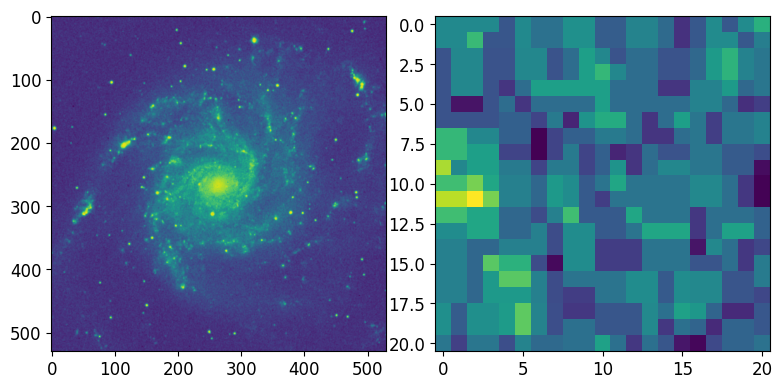

The RMS of the selected data is: 3419.889724190472
The mean of the selected data is: 3409.875283446712, with the standard deviation: 261.5268188212982


In [22]:
from astropy.io import fits
import numpy as np
from matplotlib.pyplot import figure, show


hdulist = fits.open('/Users/users/lklingens/PROGNUM-repo/Task6/m101_float.fits')  # Open file with the float numbers.
data = hdulist[0].data  # Get image data.

# Plot image to inspect for noise areas

fig = figure(figsize=(8,8))  # Create figure
frame = fig.add_subplot(1,2,1)
frame.imshow(data)

data_slice = data[:21, :21]
data_flat = data_slice.flatten()

frame2 = fig.add_subplot(1,2,2)
frame2.imshow(data_slice)
fig.tight_layout()
show()

# Calculate the RMS of the slice.

data_RMS = ((1/(len(data_flat)))*sum((data_flat)**2))**0.5

print(f"The RMS of the selected data is: {data_RMS}")

mean = np.mean(data_flat)
stdev = np.std(data_flat)
print(f"The mean of the selected data is: {mean}, with the standard deviation: {stdev}")

The RMS is better for noise than the mean, as the mean only takes the average. If the used data has a lot of outliers and/or negative values, the mean does not take those into account accordingly. The RMS can tell you the strength of a value, while the mean just takes the average and the standard deviation calculates how much the points spread out from the average.

The RMS differs from the mean because the 1/n is not squared. If the 1.n was also squared, the RMS would exaclt be the square roor of the mean^2

#### <span style="color:red"> *Question 6.5*

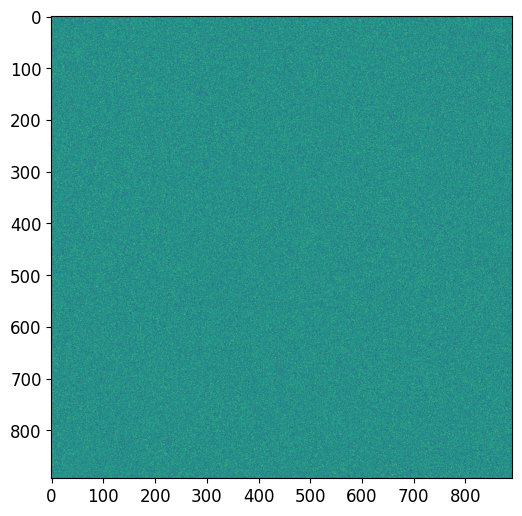

The standard deviation of all pixels in the mean image is: 5.773191380233297
The standard deviation of all three images through calculation is: 5.770294583366139
The two standard deviation values are equal up until three significant numbers.


In [23]:
from astropy.io import fits
import numpy as np
from matplotlib.pyplot import figure, show

# Open the three files and get the image data

hdulist0 = fits.open('/Users/users/lklingens/PROGNUM-repo/Task6/noisemap0.fits')
data0 = hdulist0[0].data
hdulist1 = fits.open('/Users/users/lklingens/PROGNUM-repo/Task6/noisemap1.fits')
data1 = hdulist1[0].data
hdulist2 = fits.open('/Users/users/lklingens/PROGNUM-repo/Task6/noisemap2.fits')
data2 = hdulist2[0].data

# Calculate the standard deviation of each image

stdev0 = np.std(data0)
stdev1 = np.std(data1)
stdev2 = np.std(data2)

stack_im = np.stack((data0, data1, data2), axis=0)  # Stack three images in z-direction.
mean_stack = np.mean(stack_im, axis=0)  # Calculate mean of stack in z-direction.

fig = figure(figsize=(6,6))
frame = fig.add_subplot(1,1,1)
frame.imshow(mean_stack)

show()

stdev_stack = np.std(mean_stack)
print(f"The standard deviation of all pixels in the mean image is: {stdev_stack}")

method_stdev = (1/3)*(((stdev0)**2 + (stdev1)**2 + (stdev2)**2)**0.5)
print(f"The standard deviation of all three images through calculation is: {method_stdev}")
print(f"The two standard deviation values are equal up until three significant numbers.")

#### <span style="color:red"> *Question 6.6*

The difference between reading an image and reading a table is that you have to specify the column names too when getting the primary data. Otherwise it is pretty much the same.

The difference in their data structure is that the table has more columns (or it can have), while the image only has two (or if it is a 3D structure, 3)

(A flag is a variable that (typically) holds a boolean value (True or False) to indicate whether a specific condition avent has occurred, it serves as a marker for a specific condition)

In [26]:
from astropy.io import fits
import numpy as np
from astropy.table import QTable

# Open the FITS file.
hdul = fits.open('APOGEE_stars.fits')
hdul.info()

# Access the primary data (in this case, it is a Table).
data = hdul[1].data  # Often, the first extension contains the table.
colnames = hdul[1].columns.names # List of the column names.

mask = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

data_table = QTable(data, names=colnames)  # Create a table with the data.
data_table['DATAFLAG'] = np.where(mask, 1, 0)  # Create a new column 'DATAFLAG' that checks for the mask.

good_data = data[mask]  # Application of the mask to filter out the good data.

m_G = good_data['GAIAEDR3_PHOT_G_MEAN_MAG']  # Get column with apparent G-band magnitude.
parallax = good_data['GAIAEDR3_PARALLAX']  # Get column with Gaia parallax in milliarcseconds.

distance = 1000/parallax  # Convert parallax to distance in parsec.
abs_mag_G = m_G - 5*np.log10(distance)+5  # Absolute G-band magnitude of the good data

# To append: table[colum][row] = value
data_table['ABSOLUTE_MAGNITUDE'] = -1.0  # First set all values in the abs_mag colun to -1.0
data_table['ABSOLUTE_MAGNITUDE'][data_table['DATAFLAG']==1] = abs_mag_G  # Enter the abs_mag_G values for rows where datafla=1

hdulout = fits.BinTableHDU(data_table)  # Create new table header
hdulout.writeto('APOGEE_update.fits', overwrite=True, output_verify='ignore')
hdul.close()

# Open the new file and convert to table to print it.

hdu = fits.open('APOGEE_update.fits')
data_new = hdu[1].data
data_new_cols = hdu[1].columns.names
new_data_table = QTable(data_new, names=data_new_cols)
print(new_data_table[:10])

Filename: APOGEE_stars.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (847,)   uint8   
  1  /Users/sunnyc/Downloads/allStar-dr17-synspec_rev1.fits#1    1 BinTableHDU     28   733901R x 8C   [E, E, E, E, E, K, K, E]   
GAIAEDR3_PARALLAX GAIAEDR3_PARALLAX_ERROR ... DATAFLAG ABSOLUTE_MAGNITUDE
----------------- ----------------------- ... -------- ------------------
              nan                     nan ...        0               -1.0
       0.28544167                0.019475 ...        0               -1.0
       0.08209286                0.315081 ...        0               -1.0
        1.2985312              0.00952245 ...        0               -1.0
        1.2985312              0.00952245 ...        1 2.7881603240966797
      -0.02394128               0.0450072 ...        0               -1.0
        1.3863556               0.0175672 ...        1 2.9852724075317383
         2.084405               0.0180373 ...        

#### <span style="color:red"> *Question 6.7*

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_frame = pd.read_csv('/Users/users/lklingens/PROGNUM-repo/Task6/gaiaTestData.csv')  # Load data frame

print(data_frame[:5])  # Give the first 5 rows

max_avgflux = data_frame.phot_g_mean_flux.max()  # Find the maximum
print(f"\nThe maximum in phot_g_mean_flux is: {max_avgflux}")
max_ind = data_frame['phot_g_mean_flux'].idxmax()  # Get index of maximum
max_row = data_frame.loc[max_ind]  # Get row corresonding to index
print(f"\nThe entie row with the highest mean flux is: \n{max_row}")

data_frame.sort_values(by='phot_g_mean_flux', ascending=True)

   source_id       ra  ra_error     dec  dec_error  phot_g_mean_flux  phot_g_mean_flux_error  phot_g_mean_mag  \
0   17418273  235.157     0.005  10.021      0.004         1.779e+06                 240.864           10.063   
1   17418274  235.262     0.005  10.026      0.004         1.559e+06                 210.916           10.206   
2   17418275  235.568     0.005  10.054      0.004         9.204e+05                 124.408           10.778   
3   17418276  234.735     0.005  10.140      0.004         8.075e+05                 109.289           10.921   
4   17418277  235.702     0.005  10.149      0.004         1.122e+06                 151.517           10.563   

   phot_bp_mean_flux  phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  phot_rp_mean_flux_error  \
0          1.112e+06                  713.876            10.236          858547.75                  558.201   
1          9.375e+05                  601.683            10.422          787445.80                 

,source_id,ra,ra_error,dec,dec_error,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_mag,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_mag,a_g_val,e_bp_min_rp_val
32004,17639468,0.000,0.000,0.000,0.000,3.034e+01,0.000,21.983,1.816e+01,0.000,22.203,1.573e+01,0.000,21.770,0.118,0.059
24791,17525652,0.000,0.000,0.000,0.000,3.065e+01,0.000,21.972,1.040e+01,0.000,22.809,2.400e+01,0.000,21.311,0.134,0.067
9895,17449325,0.000,0.000,0.000,0.000,3.077e+01,0.000,21.968,1.054e+01,0.000,22.794,2.389e+01,0.000,21.316,0.123,0.061
30119,17578430,0.000,0.000,0.000,0.000,3.104e+01,0.000,21.959,1.346e+01,0.000,22.529,2.091e+01,0.000,21.461,0.131,0.065
14168,17466797,0.000,0.000,0.000,0.000,3.131e+01,0.000,21.949,1.074e+01,0.000,22.774,2.435e+01,0.000,21.296,0.113,0.057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53,17418326,236.152,0.005,11.422,0.004,2.089e+07,2783.029,7.389,9.574e+06,6060.852,7.899,1.351e+07,8598.376,6.935,0.000,0.000
45,17418318,234.392,0.005,11.151,0.004,2.130e+07,2857.355,7.368,1.027e+07,6543.983,7.823,1.323e+07,8480.906,6.958,0.000,0.000
8,17418281,234.497,0.005,10.240,0.004,2.726e+07,3687.836,7.100,1.635e+07,10494.688,7.317,1.382e+07,8974.188,6.910,0.000,0.000
23,17418296,234.706,0.005,10.616,0.004,3.098e+07,4174.389,6.961,1.501e+07,9608.152,7.410,1.919e+07,12354.557,6.554,0.000,0.000


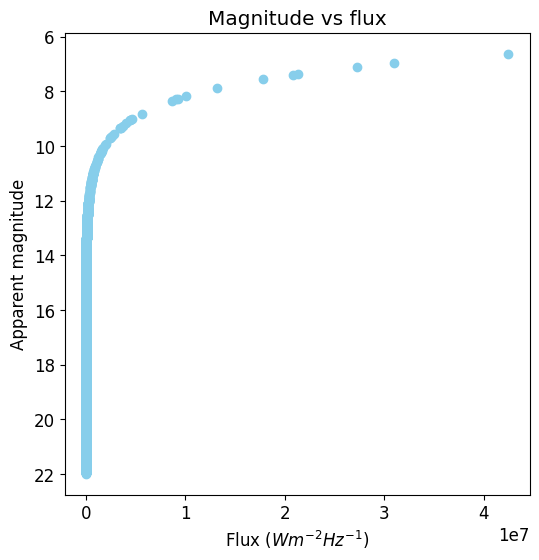

The value for m0 is: 13154.639256694456


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_frame = pd.read_csv('/Users/users/lklingens/PROGNUM-repo/Task6/gaiaTestData.csv')  # Load data frame

data_frame.sort_values(by='phot_g_mean_flux', ascending=True)[:10]  # Sort by phot_g_mean_flux and siplay first 10 rows

X = data_frame['phot_g_mean_flux']
Y = data_frame['phot_g_mean_mag']

fig = plt.figure(figsize=(6,6))  # Create figure
frame = fig.add_subplot(1,1,1)  # Add subplot

frame.scatter(X, Y, color='skyblue')
frame.set_title('Magnitude vs flux')
frame.set_xlabel(r'Flux ($W m^{-2} Hz^{-1}$)')
frame.set_ylabel('Apparent magnitude')
frame.yaxis.set_inverted(True)  # Invert y-axis

plt.show()

# Relation between flux and magnitude.

#mg = []

m_0 = X + 2.5*np.log10(Y)  # Calculate m_0 for every X and Y
m_0_mean = np.mean(m_0)
print(f"The value for m0 is: {m_0_mean}")  # Print final m_0 value

#### <span style="color:red"> *Question 6.10*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Import Gaia query module from astroquery package
from astroquery.gaia import Gaia
from astropy.table import Table

# The full query that creates the sample
full_query = '''
SELECT TOP 50
    source_id,
    ra, dec,
    parallax, parallax_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax > 10
    AND parallax/parallax_error > 5
    AND phot_g_mean_mag IS NOT NULL
    AND phot_bp_mean_mag IS NOT NULL
    AND phot_rp_mean_mag IS NOT NULL
ORDER BY random_index
'''

job = Gaia.launch_job(full_query)  # Search Gaia database
results = job.get_results()  # Get results
gaia = results.to_pandas()  # Convert results to a pandas table

gaia  # Show data as table, HTML style

gaia_table = Table.from_pandas(gaia)  # Convert data back to Astropy Table
gaia_table.write('astroquery_gaia.fits', format='fits', overwrite=True)
print(gaia_table)


ModuleNotFoundError: No module named 'astroquery'

#### <span style="color:red"> *Question 6.14*

In [38]:
N = int(input("Enter your number for N:"))
M = int(input("Enter your number for M:"))

class Fibonacci:
    """Class for calculating Fibonacci sequence."""
    previous = 0  # Starting number; previous term
    new = 1  # Second number; new term
    numbers = []  # List with numbers
    
    def __init__(self, N, M):
        self.N = N
        self.M = M
    def reset(self):
        """Function thay resent the class variables to their starting values."""
        self.previous = 0
        self.new = 1
        self.numbers = []
    def fibo_term(self):
        self.reset()  # To reset the function every time it is called.
        
        for k in range(self.N):
            following = self.previous + self.new 
            self.previous = self.new
            self.new = following
        return self.new
    def fibo_mod(self):
        self.reset()  # To reset the function every time it is called.
        
        for k in range(self.N):  # Ensures the code only runs until the Nth term.
            if self.previous % self.M == 0:
                self.numbers.append(self.previous)
            following = self.previous + self.new  # Calculates the next Fibonacci number
            self.previous = self.new
            self.new = following
        return self.numbers
    
trial = Fibonacci(N, M)
print(f"The {N}th Fibonacci term is: {trial.fibo_term()}")
print(f"The Fibonacci terms less than the {N}th term that can be divided by {M} are:\n{trial.fibo_mod()}")

Enter your number for N:100
Enter your number for M:7
The 100th Fibonacci term is: 573147844013817084101
The Fibonacci terms less than the 100th term that can be divided by 7 are:
[0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]


In [36]:
# Fibonnaci < Nth term

previous = 1
new = 2

for k in range(98): #the first two numbers are known, so we need to go 98 steps further for the 100th number
    following = previous + new 
    previous = new
    new = following

print(f"The 100th number in the Fibonacci sequence is {new}")

The 100th number in the Fibonacci sequence is 573147844013817084101


In [37]:
# Fibonacci< Nth term, %M

N = int(input("Enter your number for N:"))
M = int(input("Enter your number for M:"))

def fibo(N, M):
    """ This function returns the list of Fibonacci numbers lower than N that are able to be divided by M
    This function written by Klingens on 27-02-2026
    
    Parameters
    -----------
    N (int) the input parameter number N
    M (int) the input parameter number M
    
    Return
    -------
    numbers (list) list containing all numbers lower than N that are able to be divided by M
    """
    previous = 0
    new = 1
    numbers = []
    for k in range(N):  # Ensures the code only runs until the Nth term.
        if previous % M == 0:
            numbers.append(previous)
        following = previous + new  # Calculates the next Fibonacci number
        previous = new
        new = following
    return numbers

print(f"The Fibonacci numbers that are less than the Nth term and can be divided by M are: {fibo(N,M)}")

Enter your number for N:100
Enter your number for M:7
The Fibonacci numbers that are less than the Nth term and can be divided by M are: [0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
